# §3.2 Simple Event Log Analysis

Event-log statistics table plus two extra statistics: variant Pareto and the impact of the pre-processing filters used in §3.3.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.seeds import set_all_seeds
set_all_seeds()

import pm4py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1. Load the raw event log


In [2]:
log_path = "../data/BPI Challenge 2017.xes"
df = pm4py.read_xes(log_path)
print(f"Shape: {df.shape}")
df.head(3)

/Users/aldo/.local/share/virtualenvs/bpic17-analysis-SHcQeuZQ/lib/python3.14/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

Shape: (1202267, 19)


,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Mandatory statistics table (§3.2)


In [3]:
CASE_COL = "case:concept:name"
ACT_COL  = "concept:name"
TS_COL   = "time:timestamp"

# Variants 
variants = (
    df.sort_values([CASE_COL, TS_COL])
      .groupby(CASE_COL)[ACT_COL]
      .agg(tuple)
)

# Attribute splits
case_attrs  = [c for c in df.columns if c.startswith("case:")]
event_attrs = [c for c in df.columns if not c.startswith("case:")]

# Categorical event attributes: string/bool dtype, excluding high-cardinality identifiers
ID_COLS = {"EventID", "OfferID"}
def _is_categorical(s):
    return (
        pd.api.types.is_string_dtype(s)
        or pd.api.types.is_bool_dtype(s)
        or s.dtype == "object"
    )
categorical_event_attrs = [
    c for c in event_attrs
    if c not in ID_COLS and _is_categorical(df[c])
]

# Case length & duration
case_len = df.groupby(CASE_COL).size()
spans = df.groupby(CASE_COL)[TS_COL].agg(["min", "max"])
dur_s = (spans["max"] - spans["min"]).dt.total_seconds()

stats = pd.DataFrame([
    ("# Cases",                            f"{df[CASE_COL].nunique():,}"),
    ("# Events",                           f"{len(df):,}"),
    ("# Variants",                         f"{variants.nunique():,}"),
    ("# Case attributes",                  len(case_attrs)),
    ("# Event attributes",                 len(event_attrs)),
    ("# Categorical event attributes",     len(categorical_event_attrs)),
    ("Case length — mean",                 f"{case_len.mean():.2f}"),
    ("Case length — std",                  f"{case_len.std():.2f}"),
    ("Case duration — mean (days)",        f"{dur_s.mean() / 86400:.2f}"),
    ("Case duration — std  (days)",        f"{dur_s.std()  / 86400:.2f}"),
    ("Case duration — mean (minutes)",     f"{dur_s.mean() / 60:.2f}"),
    ("Case duration — std  (minutes)",     f"{dur_s.std()  / 60:.2f}"),
    ("Case duration — mean (seconds)",     f"{dur_s.mean():.2f}"),
    ("Case duration — std  (seconds)",     f"{dur_s.std():.2f}"),
], columns=["Statistic", "Value"])

print("Categorical event attributes:", categorical_event_attrs)
print("Case attributes:", case_attrs)
stats


Categorical event attributes: ['Action', 'org:resource', 'concept:name', 'EventOrigin', 'lifecycle:transition', 'Accepted', 'Selected']
Case attributes: ['case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount']


,Statistic,Value
0,# Cases,"31,509"
1,# Events,"1,202,267"
2,# Variants,"15,930"
3,# Case attributes,4
4,# Event attributes,15
5,# Categorical event attributes,7
6,Case length — mean,38.16
7,Case length — std,16.72
8,Case duration — mean (days),21.90
9,Case duration — std (days),13.17


Persist the table to results/.

In [4]:
Path("../results").mkdir(exist_ok=True)
stats.to_csv("../results/event_log_stats.csv", index=False)
stats.to_latex(
    "../results/event_log_stats.tex",
    index=False,
    column_format="lr",
    caption="BPIC-17 raw event-log statistics.",
    label="tab:event_log_stats",
)


## 3. Additional statistic 1: Variant Pareto

Case-mass concentration: a few variants cover most cases, a long tail drives noise. Motivates the discovery/conformance trade-off.

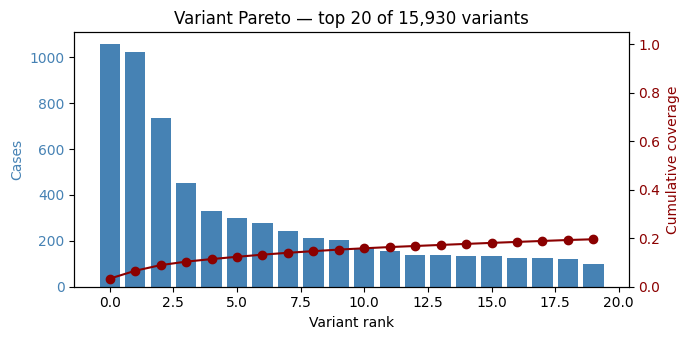

Top 20 variants cover 19.6% of all cases.
Variants needed for 80% coverage: 9629
Total variants: 15,930


In [5]:
variant_counts = variants.value_counts()
top_n = 20
cumcov = variant_counts.cumsum() / variant_counts.sum()

fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(top_n)
ax.bar(x, variant_counts.iloc[:top_n].values, color="steelblue", label="Cases (frequency)")
ax.set_xlabel("Variant rank")
ax.set_ylabel("Cases", color="steelblue")
ax.tick_params(axis="y", labelcolor="steelblue")
ax2 = ax.twinx()
ax2.plot(x, cumcov.iloc[:top_n].values, color="darkred", marker="o", label="Cumulative coverage")
ax2.set_ylabel("Cumulative coverage", color="darkred")
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis="y", labelcolor="darkred")
plt.title(f"Variant Pareto — top {top_n} of {len(variant_counts):,} variants")
fig.tight_layout()
Path("../results/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/variant_pareto.pdf")
plt.savefig("../results/figures/variant_pareto.png", dpi=150)
plt.show()

print(f"Top {top_n} variants cover {cumcov.iloc[top_n-1]:.1%} of all cases.")
print(f"Variants needed for 80% coverage: {int((cumcov < 0.80).sum()) + 1}")
print(f"Total variants: {len(variant_counts):,}")


## 4. Additional statistic 2: Impact of discovery pre-processing

How much of the log the src.preprocessing filters drop, justifying them as a small noise-removing perturbation (filters documented in §3.3).

In [6]:
from src.preprocessing import filter_for_discovery

df_filt, report = filter_for_discovery(df)

impact = pd.DataFrame([
    ("Cases",    report.cases_before,    report.cases_after,    report.cases_dropped),
    ("Events",   report.events_before,   report.events_after,   report.events_dropped),
    ("Variants", report.variants_before, report.variants_after, report.variants_dropped),
], columns=["Metric", "Raw", "Filtered", "Dropped"])
impact["Dropped %"] = (impact["Dropped"] / impact["Raw"] * 100).round(1)

impact.to_csv("../results/filter_impact.csv", index=False)
impact.to_latex(
    "../results/filter_impact.tex",
    index=False,
    column_format="lrrrr",
    caption="Effect of the pre-processing filters (lifecycle = complete, 14-day trace-boundary buffers) applied before discovery.",
    label="tab:filter_impact",
)
impact


,Metric,Raw,Filtered,Dropped,Dropped %
0,Cases,31509,31361,148,0.5
1,Events,1202267,473139,729128,60.6
2,Variants,15930,5607,10323,64.8


Save the filtered log as a pandas pickle so notebooks 02–05 skip re-parsing the large XES.

In [7]:
df_filt.to_pickle("../data/bpic17_filtered.pkl")
print(f"{len(df_filt):,} events, {df_filt[CASE_COL].nunique():,} cases")


473,139 events, 31,361 cases
